<a href="https://colab.research.google.com/github/linamendezh7/EjerciciosBIT-LinaMendez/blob/DataScience/Actividad_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problema:** Predecir el costo del seguro médico de una persona por medio de la variable númerica charges (costo del seguro)

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from matplotlib import pyplot as plt
import seaborn as sns

pd.options.mode.chained_assignment = None
pd.options.display.float_format = '{:.2f}'.format

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
proyecto= pd.read_csv("/content/drive/MyDrive/Colab Notebooks/insurance.csv")
proyecto


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55
1334,18,female,31.92,0,no,northeast,2205.98
1335,18,female,36.85,0,no,southeast,1629.83
1336,21,female,25.80,0,no,southwest,2007.94


EDA Analisis exploratorio de los datos

In [4]:
proyecto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
proyecto.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [6]:
## Revisar cantidad de valores en las columnas categoricas
for col in proyecto.select_dtypes(include=['object']).columns:
    print(col, proyecto[col].nunique())

sex 2
smoker 2
region 4


In [15]:
data_barras = pd.DataFrame(proyecto['region'].value_counts())
data_barras

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


<Axes: xlabel='count', ylabel='Count'>

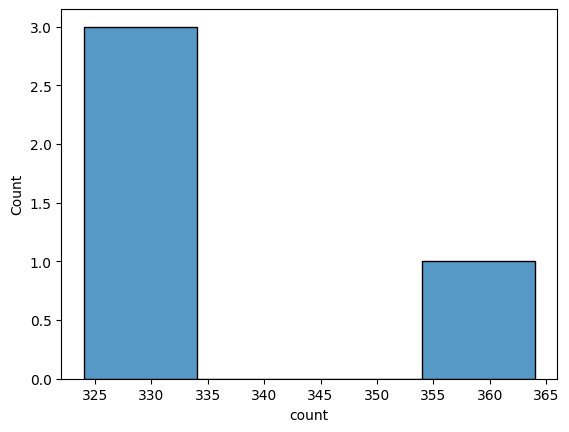

In [7]:
# Revisar categorias raras en region
proyecto['region'].value_counts()
sns.histplot(proyecto['region'].value_counts())

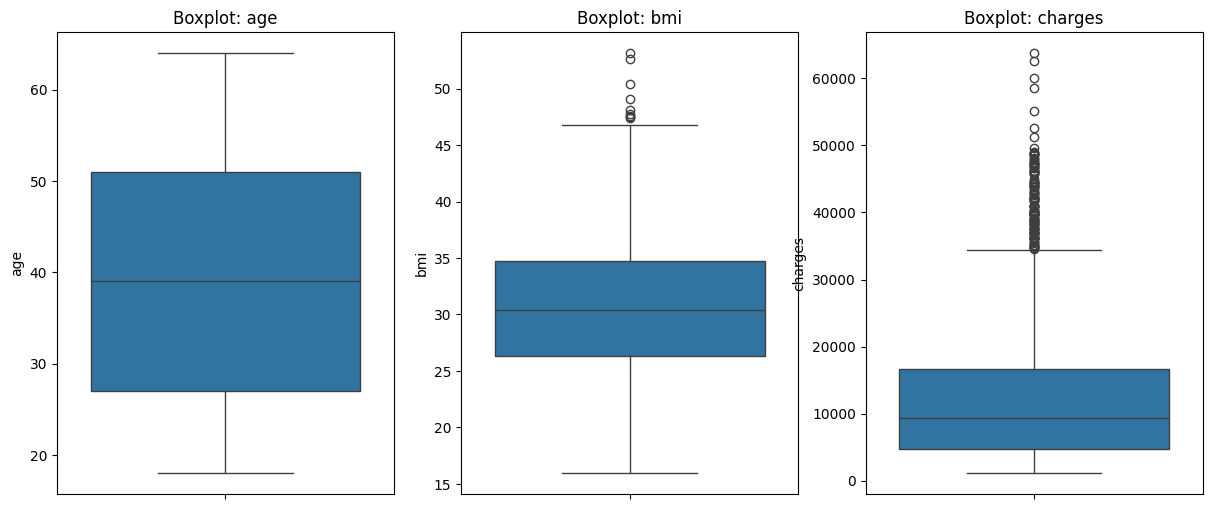

In [9]:
# boxplot para cada variable del dataset
numeric_columns=['age','bmi','charges']
fig, axs = plt.subplots(1, 4, figsize=(20,6))
for i, ax in enumerate(axs.flatten()):
    if i < len(numeric_columns):
        ax.set_title("Boxplot: " + f'{numeric_columns[i]}')
        sns.boxplot(proyecto[numeric_columns[i]], ax=ax)
    else:
        ax.set_visible(False)
plt.show()

Preprocesamiento de datos

In [10]:
proyecto['charges'].describe()

,charges
count,1338.00
mean,13270.42
std,12110.01
min,1121.87
25%,4740.29
50%,9382.03
75%,16639.91
max,63770.43


(1338, 7)
(1338, 6)


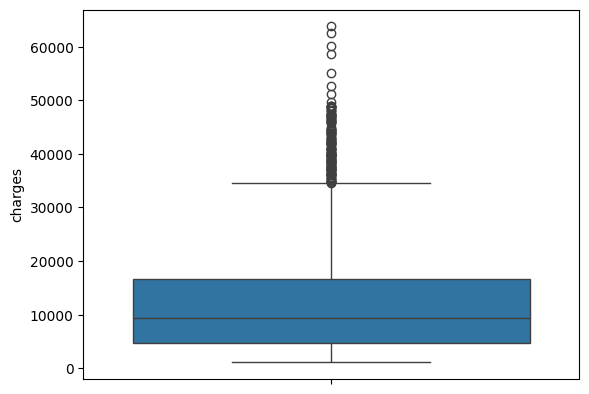

In [30]:
# Quitar registros con valores demasiado altos
df_used_charges_limpio = proyecto.copy()
df_used_charges_limpio = df_used_charges_limpio.drop(columns=['region'])
#df_used_charges_limpio = df_used_limpio[df_used_['charges'] < 35000]
sns.boxplot(df_used_charges_limpio['charges'])

print(proyecto.shape)
print(df_used_charges_limpio.shape)

In [31]:
# Agrupar las edades raras  en "Other"
umbral = 5
categorias_raras = df_used_charges_limpio['age'].value_counts()[df_used_charges_limpio['age'].value_counts() < umbral].index
df_used_charges_limpio.loc[df_used_charges_limpio['age'].isin(categorias_raras), 'age'] = 'Other'
print("Categorias: ", proyecto['age'].nunique())
print("Categorias: ", df_used_charges_limpio['age'].nunique())

Categorias:  47
Categorias:  47


/tmp/ipython-input-1636721150.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Other' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_used_charges_limpio.loc[df_used_charges_limpio['age'].isin(categorias_raras), 'age'] = 'Other'


In [32]:
# Cambiar el tipo de dato de la columna "age" a numerico
df_used_charges_limpio['age'] = pd.to_numeric(df_used_charges_limpio['age'], errors='coerce', downcast='integer')
# Llenar valores nulos y desconocidos de la columna "Cylinders" con la mediana de los datos
df_used_charges_limpio.loc[df_used_charges_limpio['age'].isna(), 'age'] = df_used_charges_limpio['age'].median()
df_used_charges_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int8   
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   charges   1338 non-null   float64
dtypes: float64(2), int64(1), int8(1), object(2)
memory usage: 53.7+ KB


## **Aplicar transformación logaritmica a la variable precio**

In [34]:
# Aplicar log-transform al charges (evitar log(0) con np.log1p)
df_used_charges_limpio["Log_Charges"] = np.log1p(df_used_charges_limpio["charges"])  # np.log1p(x) = log(x + 1)

In [35]:
df_used_charges_limpio

,age,sex,bmi,children,smoker,charges,Log_Charges
0,19,female,27.90,0,yes,16884.92,9.73
1,18,male,33.77,1,no,1725.55,7.45
2,28,male,33.00,3,no,4449.46,8.40
3,33,male,22.70,0,no,21984.47,10.00
4,32,male,28.88,0,no,3866.86,8.26
...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,10600.55,9.27
1334,18,female,31.92,0,no,2205.98,7.70
1335,18,female,36.85,0,no,1629.83,7.40
1336,21,female,25.80,0,no,2007.94,7.61


In [37]:
# Antes de la transformación
print("asimetría original:", df_used_charges_limpio["charges"].skew())

# Después de la transformación
print("asimetría log-transform:", df_used_charges_limpio["Log_Charges"].skew())

asimetría original: 1.5158796580240388
asimetría log-transform: -0.08981728740026822


<Axes: xlabel='charges', ylabel='Count'>

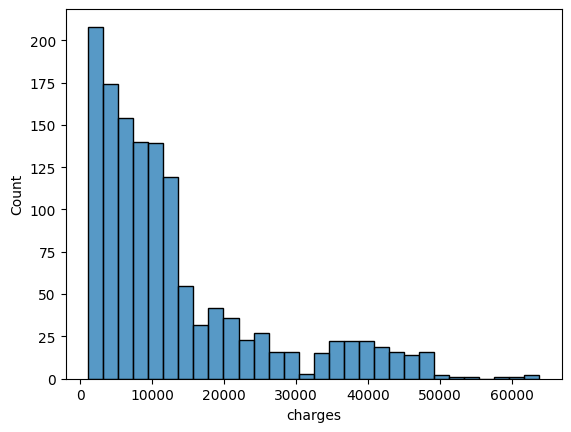

In [38]:
sns.histplot(df_used_charges_limpio["charges"])

<Axes: xlabel='Log_Charges', ylabel='Count'>

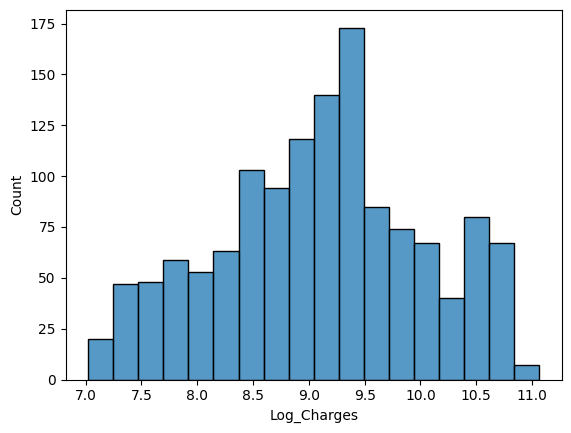

In [39]:
sns.histplot(df_used_charges_limpio["Log_Charges"])

In [41]:
df_used_charges_limpio['age'].nunique()

47

In [43]:
# TargetMean Encoding para columnas con muchas categorias
df_used_charges_limpio['Age_TargetMean'] = df_used_charges_limpio['age'].map(df_used_charges_limpio.groupby('age')['charges'].mean())

In [44]:
df_used_charges_limpio.groupby('age')['charges'].mean()

,charges
age,
18,7086.22
19,9747.91
20,10159.70
21,4730.46
22,10012.93
23,12419.82
24,10648.02
25,9838.37
26,6133.83


In [45]:
df_used_charges_limpio[['age','Age_TargetMean','charges']]

,age,Age_TargetMean,charges
0,19,9747.91,16884.92
1,18,7086.22,1725.55
2,28,9069.19,4449.46
3,33,12351.53,21984.47
4,32,9220.30,3866.86
...,...,...,...
1333,50,15663.00,10600.55
1334,18,7086.22,2205.98
1335,18,7086.22,1629.83
1336,21,4730.46,2007.94


In [47]:
# Frecuency Encoding para modelo
df_used_charges_limpio['Children_Frecuency'] = df_used_charges_limpio['children'].map(df_used_charges_limpio.groupby('children')['charges'].count())

In [48]:
df_used_charges_limpio.groupby('children')['charges'].count()

,charges
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [49]:
df_used_charges_limpio[['children','Children_Frecuency','charges']]

,children,Children_Frecuency,charges
0,0,574,16884.92
1,1,324,1725.55
2,3,157,4449.46
3,0,574,21984.47
4,0,574,3866.86
...,...,...,...
1333,3,157,10600.55
1334,0,574,2205.98
1335,0,574,1629.83
1336,0,574,2007.94


In [50]:
df_used_charges_limpio.drop(columns=['Children_Frecuency','Age_TargetMean'], inplace=True)

In [51]:
pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.1 MB/s eta 0:00:00


# **Preprocesamiento**

In [62]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor
import category_encoders as ce

df = df_used_charges_limpio.copy()
y = df["Log_Charges"]
X = df.drop(columns=["charges", "Log_Charges"])

One_hot = ['smoker']
TargetMean = ["age", 'bmi']
Frecuency = ["children"]
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("onehot", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), One_hot),

        ("target_mean", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("te", ce.TargetEncoder())
        ]), TargetMean),

        ("freq", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("fe", ce.CountEncoder(normalize=True))
        ]), Frecuency),
    ],
    remainder="passthrough"
)

# **Entrenamiento y evaluación**

In [61]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor, ExtraTreesRegressor, BaggingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

models = {
    "DT": DecisionTreeRegressor(random_state=42),
    "Bagging": BaggingRegressor(random_state=42, n_estimators=200, n_jobs=-1),
    "RF": RandomForestRegressor(random_state=42,  max_features="sqrt",max_depth=20, min_samples_split=5, n_estimators=600, n_jobs=-1),
    "AB": AdaBoostRegressor(random_state=42, n_estimators=400, learning_rate=0.05),
    #"SVR": SVR(kernel="rbf", C=10.0, gamma="scale", epsilon=0.1),
    "ET": ExtraTreesRegressor(random_state=42, n_estimators=800, n_jobs=-1, max_features="sqrt"),
    "XGB": XGBRegressor(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42,
        tree_method="hist",
        eval_metric="rmse",
        n_jobs=-1
    ),
    "Linear": LinearRegression(n_jobs=None),
    "GB": GradientBoostingRegressor(random_state=42, n_estimators=600, learning_rate=0.05, max_depth=3)
}

# ===== Funciones de métricas =====
def safe_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) < eps, eps, np.abs(y_true))
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(eps, (np.abs(y_true) + np.abs(y_pred)) / 2.0)
    return np.mean(np.abs(y_pred - y_true) / denom) * 100

# ===== Entrenar, predecir y evaluar =====
rows = []
fitted_pipelines = {}  # por si luego quieres usar el mejor
for name, reg in models.items():
    pipe = Pipeline([
        ("prep", preprocess),   # tu ColumnTransformer (imputers, scaler num, onehot, target, freq)
        ("reg", reg)
    ])
    pipe.fit(X_train, y_train)                    # y_train es Log_Price
    y_pred_log = pipe.predict(X_test)             # pred en log
    y_pred = np.expm1(y_pred_log)                 # volver a AED
    y_test_real = np.expm1(y_test)

    mse = mean_squared_error(y_test_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, y_pred)
    r2 = r2_score(y_test_real, y_pred)
    mape = safe_mape(y_test_real, y_pred)
    smape_val = smape(y_test_real, y_pred)

    rows.append({
        "Modelo": name, "R2": r2, "MAE": mae, "RMSE": rmse,
        "MAPE_%": mape, "sMAPE_%": smape_val
    })
    fitted_pipelines[name] = pipe

# **Comparación de Modelos**

In [64]:
df.describe()

,age,bmi,children,charges,Log_Charges
count,1338.00,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42,9.10
std,14.05,6.10,1.21,12110.01,0.92
min,18.00,15.96,0.00,1121.87,7.02
25%,27.00,26.30,0.00,4740.29,8.46
50%,39.00,30.40,1.00,9382.03,9.15
75%,51.00,34.69,2.00,16639.91,9.72
max,64.00,53.13,5.00,63770.43,11.06


In [65]:
results_df = pd.DataFrame(rows).sort_values(by=["R2","MAE"], ascending=[False, True]).reset_index(drop=True)
print(results_df)

    Modelo   R2     MAE    RMSE  MAPE_%  sMAPE_%
0       RF 0.88 1957.17 4353.00   17.61    17.92
1  Bagging 0.87 2126.04 4477.21   19.79    18.81
2       AB 0.86 3057.44 4699.61   40.90    33.40
3      XGB 0.86 2367.62 4722.98   22.04    20.21
4       ET 0.86 2180.88 4742.66   20.05    18.61
5       GB 0.85 2298.68 4757.37   18.82    19.21
6       DT 0.72 3043.13 6543.95   39.02    21.90
7   Linear 0.60 3968.14 7847.14   28.17    26.25


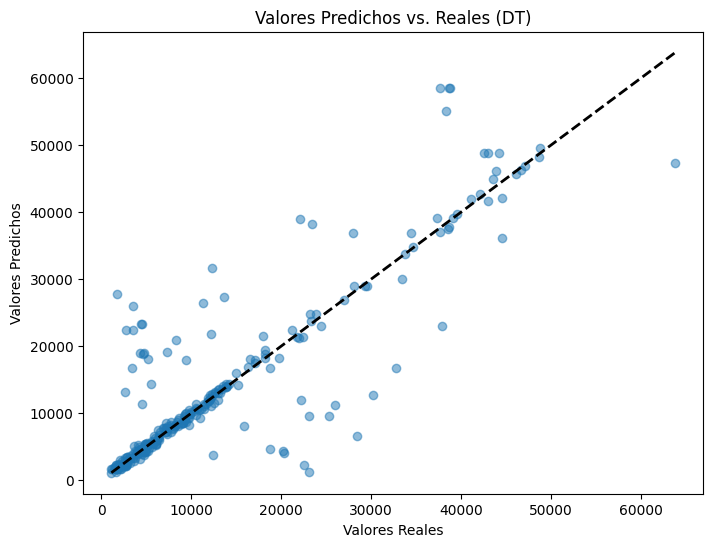

In [66]:
# Realizar predicciones con el modelo con mejor resultado

y_pred = fitted_pipelines['DT'].predict(X_test)

# Crear un gráfico de dispersión de valores predichos vs. reales
plt.figure(figsize=(8, 6))
plt.scatter(np.expm1(y_test), np.expm1(y_pred), alpha=0.5)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Predichos vs. Reales (DT)')
plt.plot([np.expm1(y_test.min()), np.expm1(y_test.max())], [np.expm1(y_test.min()), np.expm1(y_test.max())], 'k--', lw=2)  # Línea de referencia
plt.show()

# **Segmentación por Edad**

In [73]:
bins = [0, 10000, 20000, 30000, 40000, np.inf]   # <10k, 10k–20k, 20k–30k, 30k–40k, >40k
labels = ["Bajo", "Bajo-Medio", "Medio", "Medio-Alto", "Alto"]

gama = pd.cut(np.expm1(y_test), bins=bins, labels=labels)

df_eval = pd.DataFrame({
    "y_test": np.expm1(y_test),
    "y_pred": np.expm1(y_pred),
    "SeguroTipo": gama
})
df_eval["AE"] = np.abs(df_eval["y_test"] - df_eval["y_pred"])                     # error absoluto
df_eval["APE_%"] = df_eval["AE"] / df_eval["y_test"].replace(0, np.nan) * 100     # error % (cuidado con ceros)

In [75]:
df_eval.groupby("SeguroTipo").mean()

/tmp/ipython-input-501557383.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eval.groupby("SeguroTipo").mean()


,y_test,y_pred,AE,APE_%
SeguroTipo,,,,
Bajo,5048.09,6720.28,1986.41,53.18
Bajo-Medio,13521.86,14069.03,2102.14,15.58
Medio,24200.54,19666.37,8354.63,35.64
Medio-Alto,36551.79,38179.37,8024.23,22.23
Alto,45852.30,45395.32,3313.81,6.83


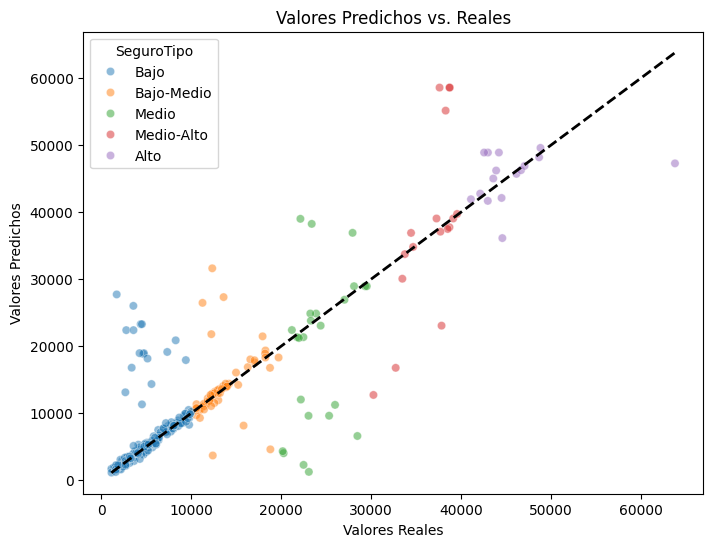

In [77]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data = df_eval, x = 'y_test', y = 'y_pred', alpha=0.5, hue='SeguroTipo')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Predichos vs. Reales')
plt.plot([df_eval['y_test'].min(), df_eval['y_test'].max()], [df_eval['y_test'].min(), df_eval['y_test'].max()], 'k--', lw=2)  # Línea de referencia
plt.show()

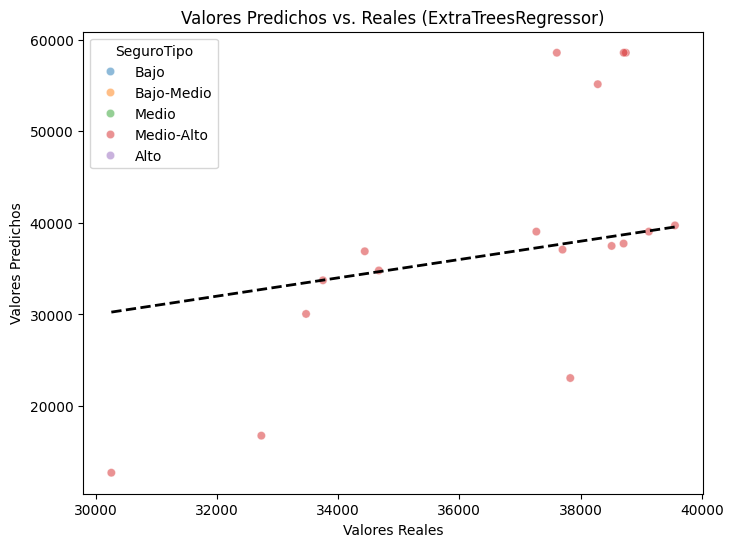

In [80]:
gama = 'Medio-Alto'
plt.figure(figsize=(8, 6))
sns.scatterplot(data = df_eval[df_eval['SeguroTipo']==gama], x = 'y_test', y = 'y_pred', alpha=0.5, hue='SeguroTipo')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Predichos vs. Reales (ExtraTreesRegressor)')
plt.plot([df_eval[df_eval['SeguroTipo']==gama]['y_test'].min(), df_eval[df_eval['SeguroTipo']==gama]['y_test'].max()], [df_eval[df_eval['SeguroTipo']==gama]['y_test'].min(), df_eval[df_eval['SeguroTipo']==gama]['y_test'].max()], 'k--', lw=2)  # Línea de referencia

In [81]:
pd.DataFrame(np.expm1(y_test), index=X_test.index)

,Log_Charges
764,9095.07
887,5272.18
890,29330.98
1293,9301.89
259,33750.29
...,...
109,47055.53
575,12222.90
535,6067.13
543,63770.43


In [82]:
pd.merge(pd.merge(X_test, pd.DataFrame(np.expm1(y_test), index=X_test.index), left_index=True, right_index=True), pd.DataFrame(np.expm1(y_pred), columns=["y_pred"], index=X_test.index), left_index=True, right_index=True)

,age,sex,bmi,children,smoker,Log_Charges,y_pred
764,45,female,25.18,2,no,9095.07,8604.48
887,36,female,30.02,0,no,5272.18,5469.01
890,64,female,26.89,0,yes,29330.98,28950.47
1293,46,male,25.75,3,no,9301.89,9500.57
259,19,male,31.92,0,yes,33750.29,33732.69
...,...,...,...,...,...,...,...
109,63,male,35.09,0,yes,47055.53,46889.26
575,58,female,27.17,0,no,12222.90,11073.18
535,38,male,28.02,1,no,6067.13,5484.47
543,54,female,47.41,0,yes,63770.43,47269.85
